## Washroom Acoustic Activity Classifier

**🛑 IMPORTANT: To process `.m4a` files, you must have `FFmpeg` installed on your system. If you are running this in Colab, it is usually pre-installed. If not, you might need to install it (e.g., `!apt-get install -y ffmpeg` in a separate cell).**

In [1]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import librosa.display
from sklearn.utils.class_weight import compute_class_weight

# Configuration constants
SAMPLE_RATE = 44000  # Audio sample rate
CHUNK_DURATION = 3  # Duration of each audio chunk in seconds
HOP_DURATION = 1     # Step size for overlapping chunks in seconds
SAMPLES_PER_CHUNK = CHUNK_DURATION * SAMPLE_RATE # Number of samples in a chunk

In [2]:
pip install soundfile

In [3]:
def map_filename_to_label(filename):
    # Assigns a class label based on keywords in the filename.
    filename_lower = filename.lower()
    if "idle" in filename_lower:
        return "silence"
    elif "tap" in filename_lower:
        return "tap_water_running"
    elif "hand" in filename_lower:
        return "handwashing"
    elif "bottle" in filename_lower or "jug" in filename_lower:
        return "filling"
    elif "clean" in filename_lower or "utensil" in filename_lower:
        return "cleaning"
    else:
        return "unknown"

# Collect all .m4a files and assign labels, separating training and unseen test data
all_m4a_files = [f for f in os.listdir('.') if f.endswith('.m4a')]
train_classified_files = []
unseen_test_classified_files = []
label_to_example_file = {} # Store one example per class for EDA (from training files only)

print("Mapping audio files to activity labels and separating into training/test sets:")
for f in all_m4a_files:
    label = map_filename_to_label(f)
    if label != "unknown":
        if "test" in f.lower():
            unseen_test_classified_files.append((f, label))
            print(f"  '[TEST] {f}' -> {label}")
        else:
            train_classified_files.append((f, label))
            if label not in label_to_example_file:
                label_to_example_file[label] = f
            print(f"  '[TRAIN] {f}' -> {label}")
    else:
        print(f"  '[UNKNOWN] {f}' -> Unknown (Skipping for training/testing)")

if not train_classified_files and not unseen_test_classified_files:
    print("\nNo recognized .m4a audio files found in the current directory. Please upload them.")
else:
    print(f"\nFound {len(train_classified_files)} training audio segments.")
    print(f"Found {len(unseen_test_classified_files)} unseen test audio segments.")
    print(f"Training classes identified: {list(label_to_example_file.keys())}")


Mapping audio files to activity labels and separating into training/test sets:
  '[TRAIN] bottle_filling_sblock47.m4a' -> filling
  '[TRAIN] bottle_filling_pdgf789.m4a' -> filling
  '[TRAIN] bottle_sblockg4.m4a' -> filling
  '[TEST] utensils_cleaning_test_pd154.m4a' -> cleaning
  '[TRAIN] handwash_pd214.m4a' -> handwashing
  '[TRAIN] idle_env_224.m4a' -> silence
  '[TRAIN] bottle_filling_pdgf3.m4a' -> filling
  '[TRAIN] just_tap_sbkockg4.m4a' -> tap_water_running
  '[TRAIN] just_tap_sblock5.m4a' -> tap_water_running
  '[TRAIN] utensils_cleaning_pd_225.m4a' -> cleaning
  '[TRAIN] jug_filling_sblock54.m4a' -> filling
  '[TRAIN] bottle_filling_pdgf78.m4a' -> filling
  '[TRAIN] bottle_filling_pdgf5.m4a' -> filling
  '[TRAIN] hand_wash_pd19.m4a' -> handwashing
  '[TRAIN] utensil_cleaning_pd107_gan.m4a' -> cleaning
  '[TRAIN] handwash_sblock58.m4a' -> handwashing
  '[TRAIN] bottle_filling_pdwr62.m4a' -> filling
  '[TRAIN] bottle_filling_pd_gf5.m4a' -> filling
  '[TRAIN] hand_washing_sblockg1

In [4]:
def extract_features_for_chunk(chunk, sr=SAMPLE_RATE, apply_frequency_masking=False):
    # Skip very short chunks
    if len(chunk) < sr * 0.01:
        return None

    # Normalize audio volume before extracting features
    chunk = librosa.util.normalize(chunk)

    # 1. Extract base MFCCs and Deltas (Pitch and Rhythm)
    mfccs = librosa.feature.mfcc(y=chunk, sr=sr, n_mfcc=13)

    if apply_frequency_masking:
        num_rows_to_mask = np.random.randint(1, 3)
        rows_to_mask = np.random.choice(mfccs.shape[0], num_rows_to_mask, replace=False)
        mfccs[rows_to_mask, :] = 0

    delta_mfccs = librosa.feature.delta(mfccs)
    delta2_mfccs = librosa.feature.delta(mfccs, order=2)

    # 2. NEW: Extract Texture Features (Harshness, Brightness, Peaks)
    zcr = librosa.feature.zero_crossing_rate(chunk)
    centroid = librosa.feature.spectral_centroid(y=chunk, sr=sr)
    contrast = librosa.feature.spectral_contrast(y=chunk, sr=sr)

    # 3. Calculate Mean, Std, Max for all features
    mfccs_mean = np.mean(mfccs.T, axis=0)
    mfccs_std = np.std(mfccs.T, axis=0)
    mfccs_max = np.max(mfccs.T, axis=0)

    delta_mean = np.mean(delta_mfccs.T, axis=0)
    delta_std = np.std(delta_mfccs.T, axis=0)
    delta_max = np.max(delta_mfccs.T, axis=0)

    delta2_mean = np.mean(delta2_mfccs.T, axis=0)
    delta2_std = np.std(delta2_mfccs.T, axis=0)
    delta2_max = np.max(delta2_mfccs.T, axis=0)

    # NEW: Average out the new texture features
    zcr_mean = np.mean(zcr.T, axis=0)
    centroid_mean = np.mean(centroid.T, axis=0)
    contrast_mean = np.mean(contrast.T, axis=0)

    # 4. Stack EVERYTHING into one massive array
    features = np.hstack([
        mfccs_mean, mfccs_std, mfccs_max,
        delta_mean, delta_std, delta_max,
        delta2_mean, delta2_std, delta2_max,
        zcr_mean, centroid_mean, contrast_mean # The new separators
    ])

    return features

In [5]:
# 4. Data Augmentation Helper Functions

def add_random_noise(signal, noise_factor=0.005):
    # Adds random white noise to an audio signal.
    noise = np.random.randn(len(signal)) # Generate Gaussian noise
    augmented_signal = signal + noise_factor * noise
    return augmented_signal

def add_random_amplitude_scaling(signal, scale_range=(0.5, 1.5)):
    # Scales the amplitude of an audio signal by a random factor.
    scale_factor = np.random.uniform(scale_range[0], scale_range[1])
    augmented_signal = signal * scale_factor
    return augmented_signal

In [6]:
# 5. Feature Extraction: Mean, Standard Deviation, Max, and Deltas

def extract_features_for_chunk(chunk, sr=SAMPLE_RATE, apply_frequency_masking=False):
    # Skip very short chunks
    if len(chunk) < sr * 0.01:
        return None

    # NEW: Normalize audio volume before extracting features
    chunk = librosa.util.normalize(chunk)

    # Extract base MFCCs
    mfccs = librosa.feature.mfcc(y=chunk, sr=sr, n_mfcc=13)

    # Apply frequency masking if augment is True
    if apply_frequency_masking:
        num_rows_to_mask = np.random.randint(1, 3)
        rows_to_mask = np.random.choice(mfccs.shape[0], num_rows_to_mask, replace=False)
        mfccs[rows_to_mask, :] = 0

    # NEW: Extract Delta and Delta-Delta MFCCs (captures rhythm)
    delta_mfccs = librosa.feature.delta(mfccs)
    delta2_mfccs = librosa.feature.delta(mfccs, order=2)

    # Calculate mean, std, max for base MFCCs
    mfccs_mean = np.mean(mfccs.T, axis=0)
    mfccs_std = np.std(mfccs.T, axis=0)
    mfccs_max = np.max(mfccs.T, axis=0)

    # Calculate mean, std, max for Delta MFCCs
    delta_mean = np.mean(delta_mfccs.T, axis=0)
    delta_std = np.std(delta_mfccs.T, axis=0)
    delta_max = np.max(delta_mfccs.T, axis=0)

    # Calculate mean, std, max for Delta-Delta MFCCs
    delta2_mean = np.mean(delta2_mfccs.T, axis=0)
    delta2_std = np.std(delta2_mfccs.T, axis=0)
    delta2_max = np.max(delta2_mfccs.T, axis=0)

    # Stack all 117 features together into a single 1D array
    features = np.hstack([
        mfccs_mean, mfccs_std, mfccs_max,
        delta_mean, delta_std, delta_max,
        delta2_mean, delta2_std, delta2_max
    ])

    return features

In [7]:
import soundfile as sf
def process_audio_file(file_path, label_str, augment=False, sr=SAMPLE_RATE, chunk_duration=CHUNK_DURATION, hop_duration=HOP_DURATION):
    # Load the audio file
    try:
        signal, _ = librosa.load(file_path, sr=sr)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return [], []

    # Apply augmentation if requested
    if augment:
        signal = add_random_noise(signal)
        signal = add_random_amplitude_scaling(signal)

    features_list = []
    labels_list = []

    # Divide the audio into overlapping chunks
    chunk_samples = int(chunk_duration * sr)
    hop_samples = int(hop_duration * sr)

    for i in range(0, len(signal) - chunk_samples + 1, hop_samples):
        chunk = signal[i:i + chunk_samples]

        # Extract features for the current chunk
        # Apply frequency masking during augmentation for features
        chunk_features = extract_features_for_chunk(chunk, sr=sr, apply_frequency_masking=augment)

        if chunk_features is not None:
            features_list.append(chunk_features)
            labels_list.append(label_str)

    return features_list, labels_list

In [24]:
import librosa
import numpy as np

# Load an example audio file
example_file = 'bottle_filling_sblock47.m4a'
signal, sr = librosa.load(example_file, sr=SAMPLE_RATE)

# Extract features for a single chunk from the example file
# Assuming the signal is long enough for at least one chunk
chunk = signal[0:SAMPLE_RATE*CHUNK_DURATION]
features = extract_features_for_chunk(chunk, sr=sr)

if features is not None:
    print(f"Shape of features extracted from '{example_file}': {features.shape}")
else:
    print(f"Could not extract features from '{example_file}'. Check if the file is valid and long enough.")

/tmp/ipykernel_12272/871392035.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(example_file, sr=SAMPLE_RATE)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Shape of features extracted from 'bottle_filling_sblock47.m4a': (117,)


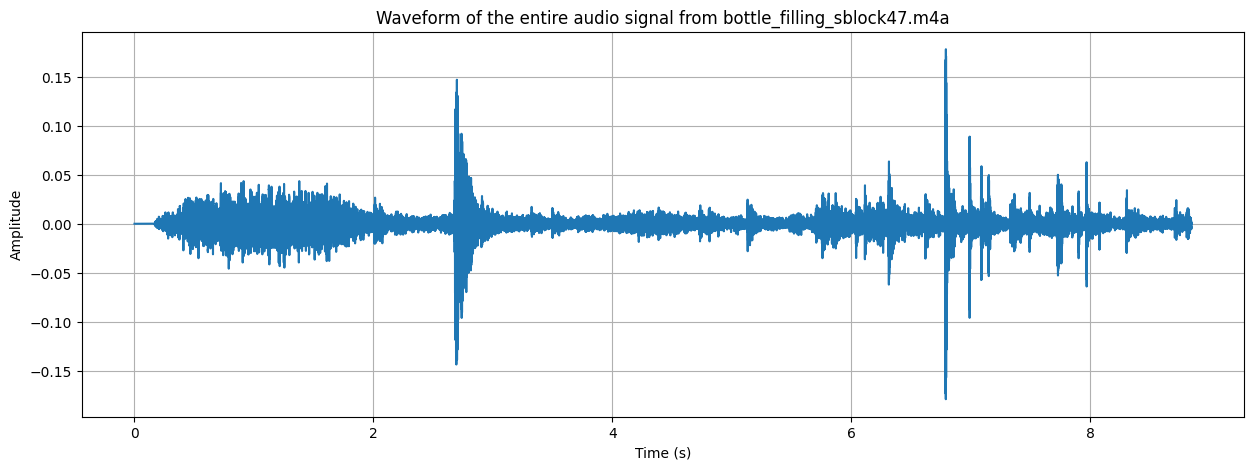

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'signal' and 'sr' are available from previous steps
# If not, ensure the previous cell is run or re-load the signal:
# example_file = 'bottle_filling_sblock47.m4a'
# signal, sr = librosa.load(example_file, sr=SAMPLE_RATE)

# Plot the entire signal
time = np.linspace(0, len(signal) / sr, len(signal))
plt.figure(figsize=(15, 5))
plt.plot(time, signal)
plt.title(f'Waveform of the entire audio signal from {example_file}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()


--- Starting Data Processing and Model Training ---

--- Processing Training Data ---
Extracting features and applying augmentation for training files...


/tmp/ipykernel_12272/360326802.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(file_path, sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_12272/360326802.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(file_path, sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_12272/360326802.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(file_path, sr=sr)
/usr/local/lib/python3.12/dist-packages

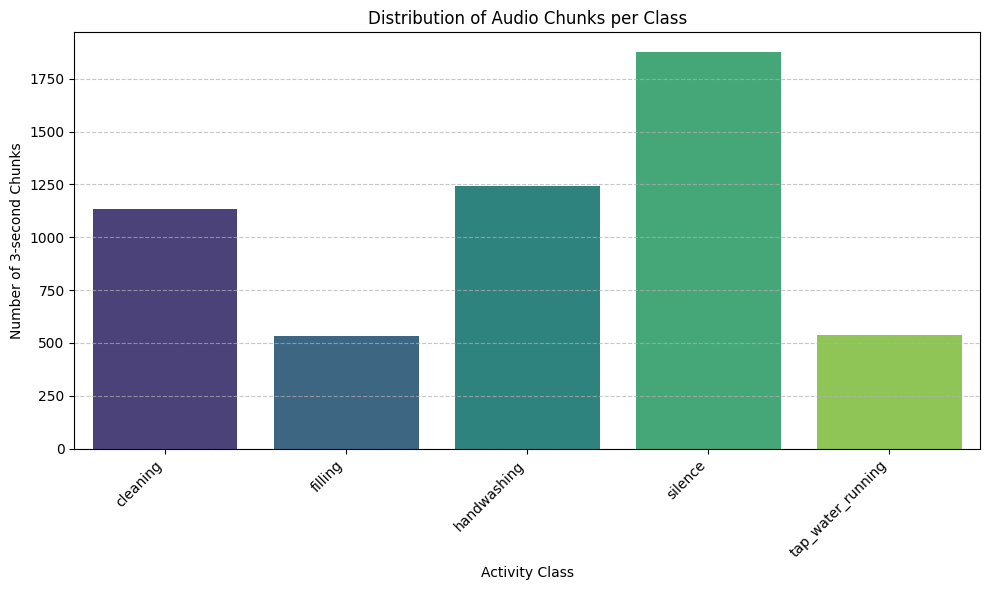

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 6. Data Loading, Feature Extraction, and Model Development
print("\n--- Starting Data Processing and Model Training ---")

# --- Part 1: Process Training Data ---
print("\n--- Processing Training Data ---")
X_train_raw = []
y_train_raw = []

print("Extracting features and applying augmentation for training files...")
for file_path, label_str in train_classified_files:
    # Process original chunks
    features_orig, labels_orig = process_audio_file(file_path, label_str, augment=False)
    X_train_raw.extend(features_orig)
    y_train_raw.extend(labels_orig)

    # Process augmented chunks
    features_aug, labels_aug = process_audio_file(file_path, label_str, augment=True)
    X_train_raw.extend(features_aug)
    y_train_raw.extend(labels_aug)

X_train_raw = np.array(X_train_raw)
y_train_raw = np.array(y_train_raw)
# Get the counts for each class
class_counts = pd.Series(y_train_raw).value_counts().sort_index()

# Create a DataFrame for plotting
class_distribution_df = pd.DataFrame({
    'Class': class_counts.index,
    'Number of Chunks': class_counts.values
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Class', y='Number of Chunks', data=class_distribution_df, palette='viridis')
plt.title('Distribution of Audio Chunks per Class')
plt.xlabel('Activity Class')
plt.ylabel('Number of 3-second Chunks')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Total 5326 training feature vectors extracted.
Encoded labels: [np.str_('cleaning'), np.str_('filling'), np.str_('handwashing'), np.str_('silence'), np.str_('tap_water_running')]

Split training data: 4260 for training, 1066 for validation.

Applying SMOTE to balance the training data...
Training chunks AFTER SMOTE: 7500 (Classes are now perfectly equal)
Features scaled (training and validation sets).
Building the classification model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        15,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,685 (92.52 KB)

 Trainable params: 23,685 (92.52 KB)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7120 - loss: 0.7578 - val_accuracy: 0.9099 - val_loss: 0.2685
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8813 - loss: 0.3313 - val_accuracy: 0.9456 - val_loss: 0.1610
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9257 - loss: 0.2107 - val_accuracy: 0.9625 - val_loss: 0.1270
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9456 - loss: 0.1574 - val_accuracy: 0.9690 - val_loss: 0.1036
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9555 - loss: 0.1264 - val_accuracy: 0.9662 - val_loss: 0.0973
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9647 - loss: 0.1058 - val_accuracy: 0.9719 - val_loss: 0.0834
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9697 - loss: 0.0913 - val_accuracy: 0.9737 - val_loss: 0.0830
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9709 - l

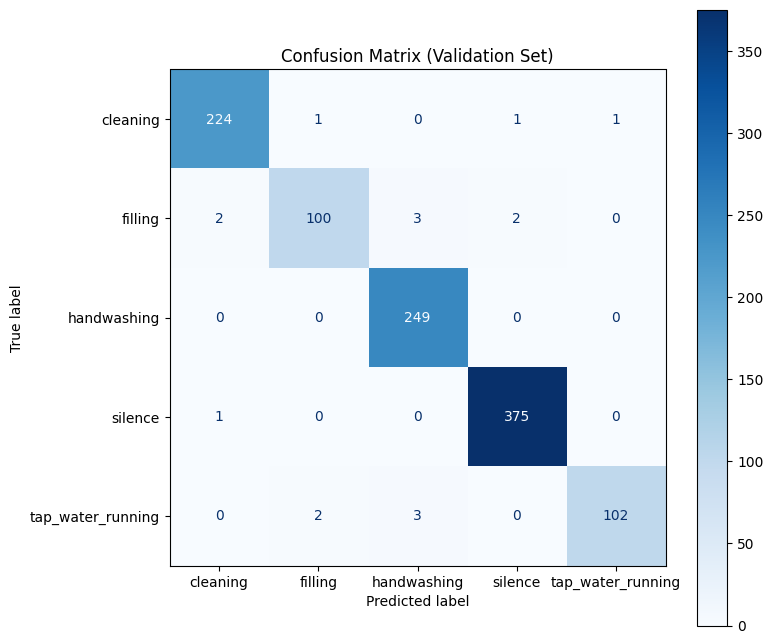


--- Processing Unseen Test Data for New-Environment Inference ---
Extracting features from unseen test files (no augmentation)...


/tmp/ipykernel_12272/360326802.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(file_path, sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_12272/360326802.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(file_path, sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_12272/360326802.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(file_path, sr=sr)
/usr/local/lib/python3.12/dist-packages

Total 436 unseen test feature vectors to predict.
Performing inference on unseen test data...

Classification Report 2 (New-Environment Inference - aggregated):
                   precision    recall  f1-score   support

         cleaning       1.00      0.80      0.89        91
          filling       0.44      1.00      0.61        22
      handwashing       1.00      0.98      0.99        87
          silence       0.88      0.98      0.92       138
tap_water_running       0.91      0.68      0.78        98

         accuracy                           0.88       436
        macro avg       0.84      0.89      0.84       436
     weighted avg       0.91      0.88      0.88       436



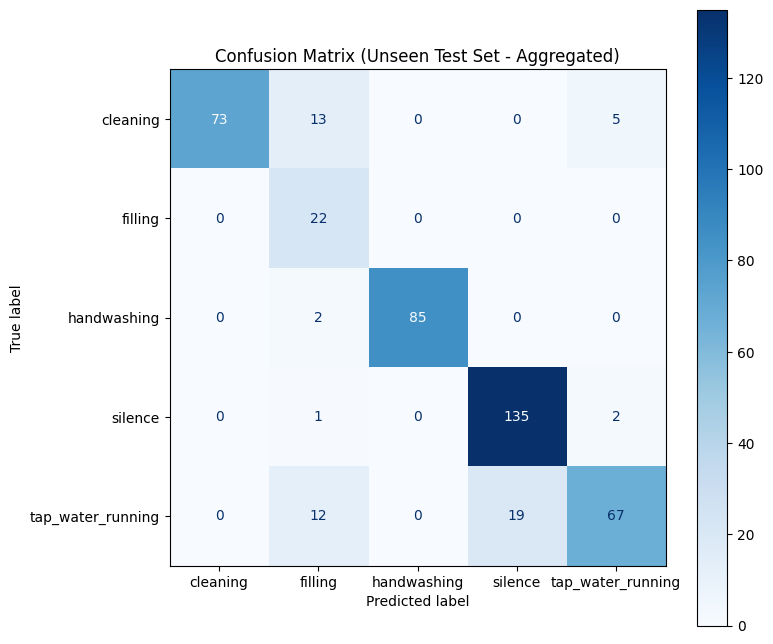


--- Data Processing and Model Training/Evaluation Complete ---


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from imblearn.over_sampling import SMOTE  # NEW: Added SMOTE import
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay # Added confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


if len(X_train_raw) == 0:
    print("Error: No training features extracted. Please check audio files and mapping.")
else:
    print(f"Total {len(X_train_raw)} training feature vectors extracted.")

    # Encode string labels to integers
    label_encoder = LabelEncoder()
    y_encoded_train_raw = label_encoder.fit_transform(y_train_raw)
    num_classes = len(label_encoder.classes_)
    print(f"Encoded labels: {list(label_encoder.classes_)}")

    # Split training data into actual training (80%) and validation (20%)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_raw, y_encoded_train_raw, test_size=0.2, random_state=42, stratify=y_encoded_train_raw
    )
    print(f"\nSplit training data: {len(X_train)} for training, {len(X_val)} for validation.")

    # ==========================================
    # NEW: APPLY SMOTE TO FIX CLASS IMBALANCE
    # ==========================================
    print("\nApplying SMOTE to balance the training data...")
    smote = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    print(f"Training chunks AFTER SMOTE: {len(X_train_balanced)} (Classes are now perfectly equal)")

    # Calculate class weights (Optional now because SMOTE balanced it, but safe to keep)
    class_weights_raw = compute_class_weight('balanced', classes=np.unique(y_train_balanced), y=y_train_balanced)
    class_weights = {i : class_weights_raw[i] for i in range(len(class_weights_raw))}

    # Scale features using StandardScaler (fit ONLY on the new balanced training data)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_balanced)
    X_val_scaled = scaler.transform(X_val)
    print("Features scaled (training and validation sets).")

    # Build the Deep Learning classification model
    print("Building the classification model...")
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dropout(0.4), # NEW: Increased from 0.3 to prevent overfitting on SMOTE data
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    # Compile the model
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    model.summary()

    # Train the model
    print("\nStarting model training...")
    history = model.fit(X_train_scaled, y_train_balanced, # NEW: Training on the balanced y labels
                        epochs=50,
                        batch_size=32,
                        validation_data=(X_val_scaled, y_val), # Validating on untouched data
                        class_weight=class_weights,
                        verbose=1)

    # Evaluate the model on the validation set
    loss_val, accuracy_val = model.evaluate(X_val_scaled, y_val, verbose=0)
    print(f"\nTraining complete! Validation Accuracy: {accuracy_val*100:.2f}%")

    # --- Classification Report 1: Validation Set ---
    y_pred_val_probs = model.predict(X_val_scaled, verbose=0)
    y_pred_val = np.argmax(y_pred_val_probs, axis=1)
    print("\nClassification Report 1 (Validation Set - same environment):")
    print(classification_report(y_val, y_pred_val, target_names=label_encoder.classes_))

    # --- Confusion Matrix 1: Validation Set ---
    cm_val = confusion_matrix(y_val, y_pred_val)
    disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=label_encoder.classes_)
    fig_val, ax_val = plt.subplots(figsize=(8, 8))
    disp_val.plot(cmap=plt.cm.Blues, ax=ax_val)
    plt.title('Confusion Matrix (Validation Set)')
    plt.show()

    # --- Part 2: Process Unseen Test Data and Inference ---
    print("\n--- Processing Unseen Test Data for New-Environment Inference ---")
    X_unseen_test_raw = []
    y_unseen_test_true_labels = []

    if not unseen_test_classified_files:
        print("No unseen test files found to perform new-environment inference.")
    else:
        print("Extracting features from unseen test files (no augmentation)...")
        for file_path, label_str in unseen_test_classified_files:
            features, labels = process_audio_file(file_path, label_str, augment=False)
            X_unseen_test_raw.extend(features)
            y_unseen_test_true_labels.extend(labels)

        X_unseen_test_raw = np.array(X_unseen_test_raw)
        y_encoded_unseen_test = label_encoder.transform(y_unseen_test_true_labels)

        if len(X_unseen_test_raw) == 0:
            print("No features extracted from unseen test files.")
        else:
            # Scale unseen test features using the *same scaler* fitted during training
            X_unseen_test_scaled = scaler.transform(X_unseen_test_raw)
            print(f"Total {len(X_unseen_test_scaled)} unseen test feature vectors to predict.")

            # Make predictions on the unseen test data
            print("Performing inference on unseen test data...")
            y_pred_unseen_probs = model.predict(X_unseen_test_scaled, verbose=0)
            y_pred_unseen = np.argmax(y_pred_unseen_probs, axis=1)

            # --- Classification Report 2: New-Environment Inference ---
            print("\nClassification Report 2 (New-Environment Inference - aggregated):")
            print(classification_report(y_encoded_unseen_test, y_pred_unseen, target_names=label_encoder.classes_))

            # --- Confusion Matrix 2: Unseen Test Set ---
            cm_unseen = confusion_matrix(y_encoded_unseen_test, y_pred_unseen)
            disp_unseen = ConfusionMatrixDisplay(confusion_matrix=cm_unseen, display_labels=label_encoder.classes_)
            fig_unseen, ax_unseen = plt.subplots(figsize=(8, 8))
            disp_unseen.plot(cmap=plt.cm.Blues, ax=ax_unseen)
            plt.title('Confusion Matrix (Unseen Test Set - Aggregated)')
            plt.show()

print("\n--- Data Processing and Model Training/Evaluation Complete ---")


### Class Distribution Visualization

Let's visualize the distribution of audio chunks across each class to check for potential dataset imbalance. This plot will show you how many samples (chunks) are available for training for each activity.

/tmp/ipykernel_12272/2489890995.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Number of Chunks', data=class_distribution_df, palette='viridis')


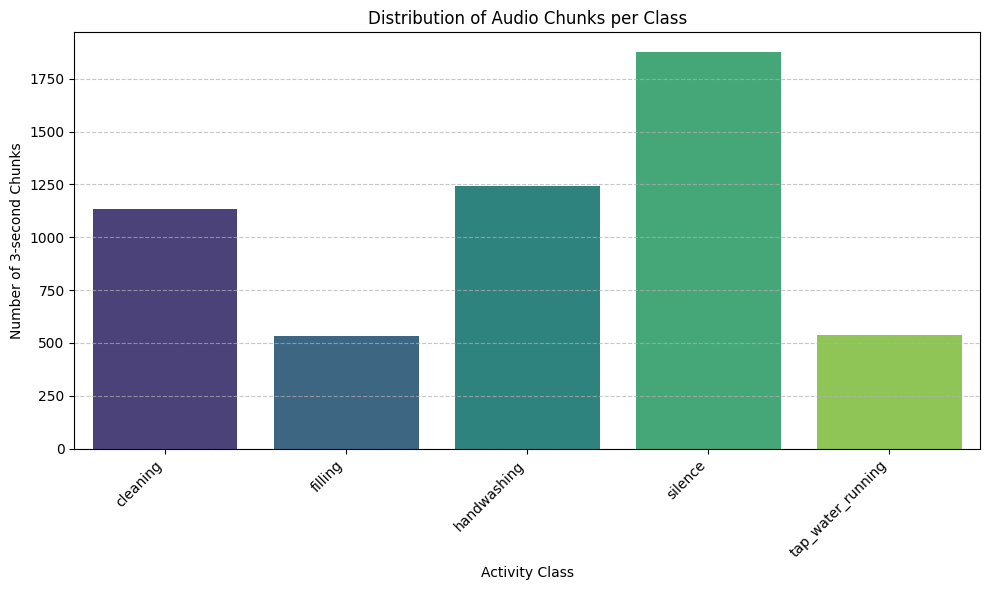

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get the counts for each class
class_counts = pd.Series(y_train_raw).value_counts().sort_index()

# Create a DataFrame for plotting
class_distribution_df = pd.DataFrame({
    'Class': class_counts.index,
    'Number of Chunks': class_counts.values
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Class', y='Number of Chunks', data=class_distribution_df, palette='viridis')
plt.title('Distribution of Audio Chunks per Class')
plt.xlabel('Activity Class')
plt.ylabel('Number of 3-second Chunks')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

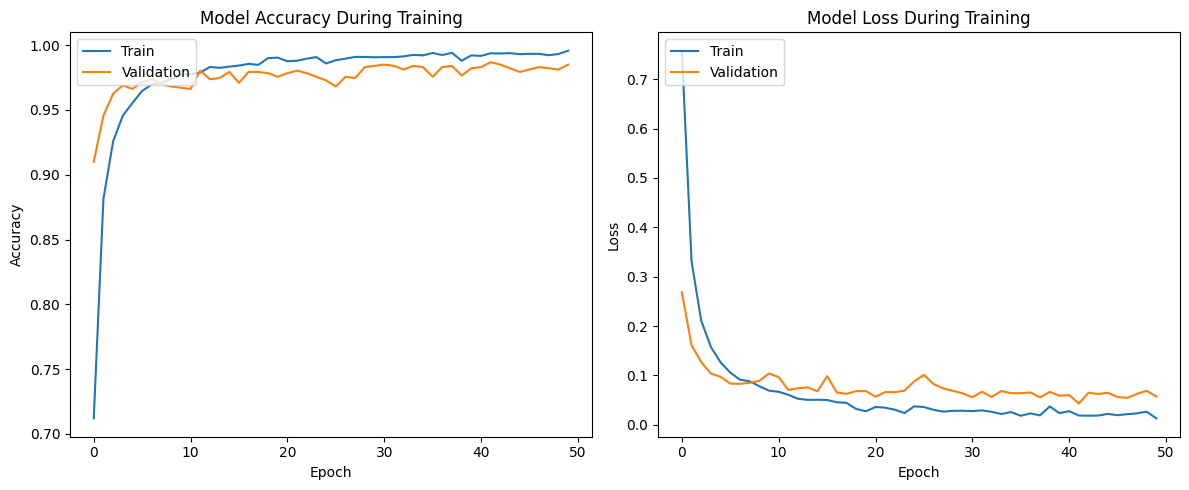

In [11]:
# 7. Analyze Classifier Training History
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy During Training')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss During Training')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

In [12]:
# 8. Save the Trained Model
model_filename = 'washroom_activity_classifier.keras'
model.save(model_filename)
print(f"Model saved as '{model_filename}'")

Model saved as 'washroom_activity_classifier.keras'


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        15,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,057 (277.57 KB)

 Trainable params: 23,685 (92.52 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 47,372 (185.05 KB)

### Model Quantization

Model quantization is a technique to reduce the size and computational cost of a machine learning model by converting its weights and activations to lower-precision data types (e.g., from floating-point to 8-bit integers). This can significantly speed up inference and reduce memory usage, especially on edge devices, with minimal impact on accuracy. We will use TensorFlow Lite for post-training quantization.

In [14]:
import tensorflow as tf

# Convert the Keras model to a TensorFlow Lite model
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Enable default optimizations, which include quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert to TensorFlow Lite model
tflite_quant_model = converter.convert()

# Save the quantized model
quantized_model_filename = 'washroom_activity_classifier_quantized.tflite'
with open(quantized_model_filename, 'wb') as f:
    f.write(tflite_quant_model)

print(f"Quantized model saved as '{quantized_model_filename}'")

Saved artifact at '/tmp/tmp26e27gyj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 117), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  136104210729104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136104210730832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136104210732176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136104210730448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136104210730256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136104210732368: TensorSpec(shape=(), dtype=tf.resource, name=None)
Quantized model saved as 'washroom_activity_classifier_quantized.tflite'


In [15]:
import os

# Compare model sizes
original_model_size = os.path.getsize(model_filename) / (1024 * 1024) # MB
quantized_model_size = os.path.getsize(quantized_model_filename) / (1024 * 1024) # MB

print(f"\nOriginal model size: {original_model_size:.2f} MB")
print(f"Quantized model size: {quantized_model_size:.2f} MB")
print(f"Size reduction: {((original_model_size - quantized_model_size) / original_model_size * 100):.2f}%")


Original model size: 0.30 MB
Quantized model size: 0.03 MB
Size reduction: 90.55%


### Evaluate Quantized Model Performance

Now, let's evaluate the performance of the quantized model on the unseen test data. We will compare its classification report and confusion matrix against the full-precision model to see the impact of quantization on accuracy.


--- Evaluating Quantized Model --- 

Classification Report (Quantized Model on Unseen Test Set - Aggregated):
                   precision    recall  f1-score   support

         cleaning       1.00      0.81      0.90        91
          filling       0.44      1.00      0.61        22
      handwashing       1.00      0.99      0.99        87
          silence       0.88      0.98      0.93       138
tap_water_running       0.92      0.68      0.78        98

         accuracy                           0.88       436
        macro avg       0.85      0.89      0.84       436
     weighted avg       0.92      0.88      0.89       436



/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


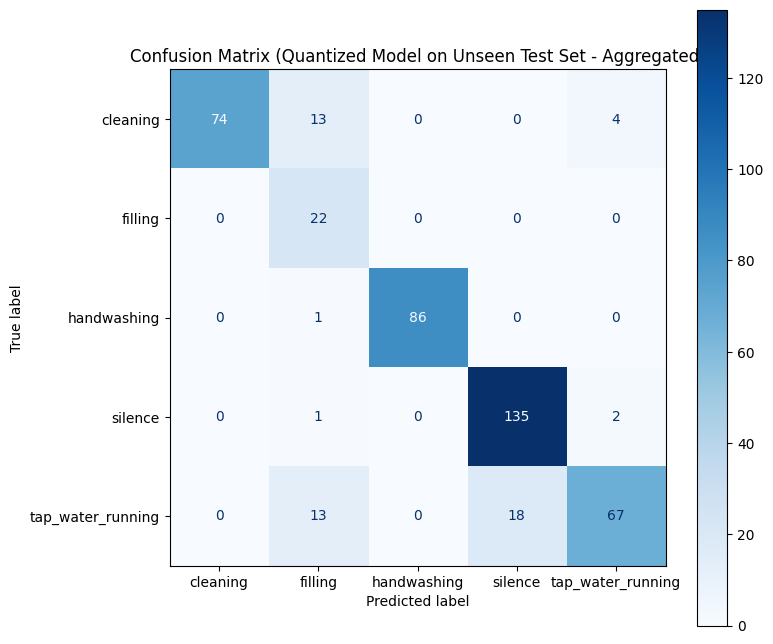


--- Quantized Model Evaluation Complete ---


In [16]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("\n--- Evaluating Quantized Model --- ")

# Load the TFLite model and allocate tensors.
interpreter = tf.lite.Interpreter(model_path=quantized_model_filename)
interpreter.allocate_tensors()

# Get input and output tensors.
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Check if unseen test data exists
if len(X_unseen_test_scaled) == 0:
    print("No scaled unseen test features available to evaluate the quantized model.")
else:
    # The input tensor is expected to be float32
    input_shape = input_details[0]['shape']
    input_data = X_unseen_test_scaled.astype(np.float32)

    # Prepare for predictions
    quantized_predictions = []

    # Process data in batches or one by one if batching is not explicitly handled by TFLite
    for i in range(len(input_data)):
        interpreter.set_tensor(input_details[0]['index'], input_data[i:i+1]) # Process one sample at a time
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_details[0]['index'])
        quantized_predictions.append(output_data[0])

    y_pred_quantized = np.argmax(np.array(quantized_predictions), axis=1)

    # --- Classification Report for Quantized Model ---
    print("\nClassification Report (Quantized Model on Unseen Test Set - Aggregated):")
    print(classification_report(y_encoded_unseen_test, y_pred_quantized, target_names=label_encoder.classes_))

    # --- Confusion Matrix for Quantized Model ---
    cm_quantized = confusion_matrix(y_encoded_unseen_test, y_pred_quantized)
    disp_quantized = ConfusionMatrixDisplay(confusion_matrix=cm_quantized, display_labels=label_encoder.classes_)
    fig_quantized, ax_quantized = plt.subplots(figsize=(8, 8))
    disp_quantized.plot(cmap=plt.cm.Blues, ax=ax_quantized)
    plt.title('Confusion Matrix (Quantized Model on Unseen Test Set - Aggregated)')
    plt.show()

print("\n--- Quantized Model Evaluation Complete ---")

### Analyze Classifier Training History

Let's visualize the training and validation accuracy and loss over epochs for the classification model. This will help us understand if the model is overfitting, underfitting, or if the training is unstable.

In [28]:
import os
import time
import numpy as np
import tensorflow as tf

def evaluate_edge_metrics(tflite_file, num_features):
    input_shape = (1, num_features)

    # 1. Measure Model File Size
    model_size_kb = os.path.getsize(tflite_file) / 1024.0
    print(f"--- Metrics for '{tflite_file}' ---")
    print(f"Model Size: {model_size_kb:.2f} KB")

    # 2. Load the TFLite Interpreter
    interpreter = tf.lite.Interpreter(model_path=tflite_file)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    input_dtype = input_details[0]['dtype']

    # 3. Create dummy data matching your exact input shape
    if input_dtype == np.int8:
        dummy_input = np.random.randint(-128, 127, size=input_shape, dtype=np.int8)
    else:
        dummy_input = np.random.rand(*input_shape).astype(np.float32)

    # 4. Warm-up the interpreter
    for _ in range(10):
        interpreter.set_tensor(input_details[0]['index'], dummy_input)
        interpreter.invoke()

    # 5. Measure Average Latency (Speed) over 100 runs
    start_time = time.time()
    for _ in range(100):
        interpreter.set_tensor(input_details[0]['index'], dummy_input)
        interpreter.invoke()
        _ = interpreter.get_tensor(output_details[0]['index'])
    end_time = time.time()

    avg_latency_ms = ((end_time - start_time) / 100.0) * 1000.0
    print(f"Average Inference Latency: {avg_latency_ms:.2f} milliseconds\n")


# === SAVE UNQUANTIZED MODEL (To compare metrics) ===
unquantized_filename = 'washroom_activity_classifier.tflite'
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_unquantized_model = converter.convert()
with open(unquantized_filename, 'wb') as f:
    f.write(tflite_unquantized_model)

# === RUN THE EVALUATION ===
# Automatically getting the exact number of features you extracted
exact_feature_count = X_train_scaled.shape[1]

evaluate_edge_metrics('washroom_activity_classifier.tflite', exact_feature_count)
evaluate_edge_metrics('washroom_activity_classifier_quantized.tflite', exact_feature_count)

Saved artifact at '/tmp/tmpih25ilm9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 117), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  136104210729104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136104210730832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136104210732176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136104210730448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136104210730256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136104210732368: TensorSpec(shape=(), dtype=tf.resource, name=None)
--- Metrics for 'washroom_activity_classifier.tflite' ---
Model Size: 94.57 KB
Average Inference Latency: 0.01 milliseconds

--- Metrics for 'washroom_activity_classifier_quantized.tflite' ---
Model Size: 28.99 KB
Average Inference Latency: 0.01 milliseconds



/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



--- Testing Chunk Size: 3 seconds ---


/tmp/ipykernel_12272/360326802.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(file_path, sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_12272/360326802.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(file_path, sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_12272/360326802.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(file_path, sr=sr)
/usr/local/lib/python3.12/dist-packages

-> Unseen Test Examples Extracted: 292
-> Unseen Overall Accuracy: 0.818
-> Unseen 'Bottle Filling' F1: 0.491 | Unseen Overall Macro F1: 0.769

--- Testing Chunk Size: 5 seconds ---


/tmp/ipykernel_12272/360326802.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(file_path, sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_12272/360326802.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(file_path, sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_12272/360326802.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(file_path, sr=sr)
/usr/local/lib/python3.12/dist-packages

-> Unseen Test Examples Extracted: 172
-> Unseen Overall Accuracy: 0.895
-> Unseen 'Bottle Filling' F1: 0.696 | Unseen Overall Macro F1: 0.865

--- Testing Chunk Size: 8 seconds ---


...

-> Unseen Test Examples Extracted: 106
-> Unseen Overall Accuracy: 0.877
-> Unseen 'Bottle Filling' F1: 0.909 | Unseen Overall Macro F1: 0.880

--- Testing Chunk Size: 12 seconds ---


/tmp/ipykernel_12272/360326802.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(file_path, sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_12272/360326802.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(file_path, sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_12272/360326802.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(file_path, sr=sr)
/usr/local/lib/python3.12/dist-packages

-> Unseen Test Examples Extracted: 67
-> Unseen Overall Accuracy: 0.970
-> Unseen 'Bottle Filling' F1: 1.000 | Unseen Overall Macro F1: 0.972

--- Testing Chunk Size: 15 seconds ---


/tmp/ipykernel_12272/360326802.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(file_path, sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_12272/360326802.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(file_path, sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_12272/360326802.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(file_path, sr=sr)
/usr/local/lib/python3.12/dist-packages

-> Unseen Test Examples Extracted: 52
-> Unseen Overall Accuracy: 0.962
-> Unseen 'Bottle Filling' F1: 1.000 | Unseen Overall Macro F1: 0.965


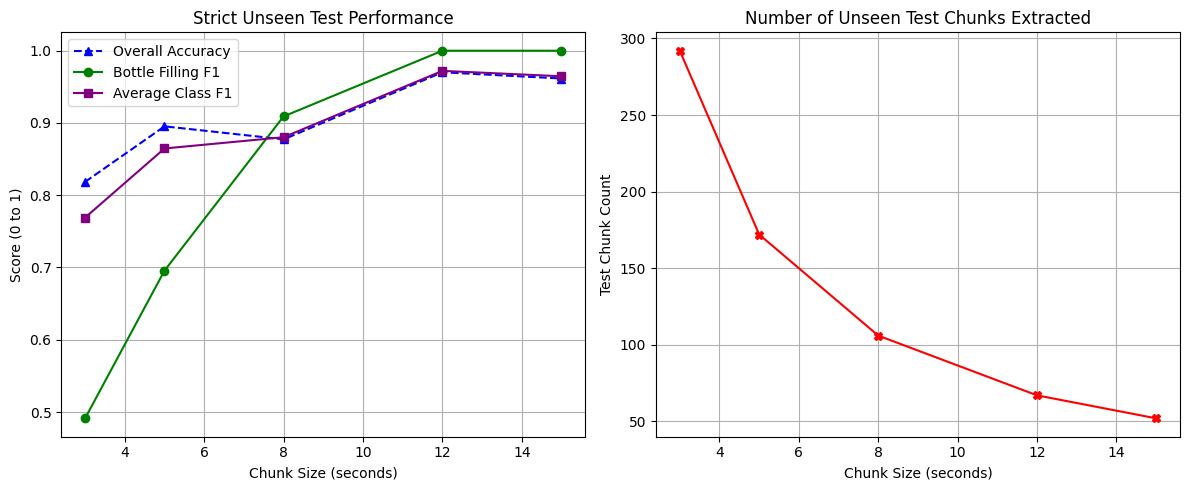

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. Define the chunk durations you want to test (in seconds)
chunk_sizes_to_test = [3, 5, 8, 12, 15]

# Dictionary to store metrics specifically for the UNSEEN TEST set
results = {
    'chunk_size': [],
    'num_train_examples': [],
    'num_test_examples': [],
    'unseen_acc': [],
    'unseen_filling_f1': [],
    'unseen_macro_f1': []
}

if not unseen_test_classified_files:
    print("WARNING: 'unseen_test_classified_files' is empty. Please make sure you have files with 'test' in their name.")

for chunk_size in chunk_sizes_to_test:
    print(f"\n==================================================")
    print(f"--- Testing Chunk Size: {chunk_size} seconds ---")
    print(f"==================================================")

    # --- A. Process Training Data ---
    X_train_temp = []
    y_train_temp = []

    for file_path, label_str in train_classified_files:
        f_orig, l_orig = process_audio_file(file_path, label_str, augment=False, chunk_duration=chunk_size, hop_duration=chunk_size / 2.0)
        if f_orig:
            X_train_temp.extend(f_orig)
            y_train_temp.extend(l_orig)

        f_aug, l_aug = process_audio_file(file_path, label_str, augment=True, chunk_duration=chunk_size, hop_duration=chunk_size / 2.0)
        if f_aug:
            X_train_temp.extend(f_aug)
            y_train_temp.extend(l_aug)

    X_train_temp = np.array(X_train_temp)
    y_train_temp = np.array(y_train_temp)

    if len(X_train_temp) == 0:
        print(f"Skipping {chunk_size}s due to lack of training chunks.")
        continue

    # --- B. Process Unseen Test Data ---
    X_test_temp = []
    y_test_temp = []

    for file_path, label_str in unseen_test_classified_files:
        # No augmentation on unseen test data
        f_test, l_test = process_audio_file(file_path, label_str, augment=False, chunk_duration=chunk_size, hop_duration=chunk_size / 2.0)
        if f_test:
            X_test_temp.extend(f_test)
            y_test_temp.extend(l_test)

    X_test_temp = np.array(X_test_temp)
    y_test_temp = np.array(y_test_temp)

    if len(X_test_temp) == 0:
        print(f"Skipping {chunk_size}s due to lack of test chunks (Test files might be shorter than {chunk_size}s).")
        continue

    # --- C. Prepare, Encode, and Scale ---
    le = LabelEncoder()
    # Fit encoder on training data to ensure consistency
    y_train_encoded = le.fit_transform(y_train_temp)

    # Transform test labels (handle unknown classes safely just in case)
    # We only keep test examples where the label exists in training
    valid_test_indices = [i for i, label in enumerate(y_test_temp) if label in le.classes_]
    X_test_temp = X_test_temp[valid_test_indices]
    y_test_temp = y_test_temp[valid_test_indices]
    y_test_encoded = le.transform(y_test_temp)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_temp)
    X_test_scaled = scaler.transform(X_test_temp) # Transform test data using TRAIN scaler

    # SMOTE for imbalance
    smote = SMOTE(random_state=42)
    try:
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train_encoded)
    except Exception as e:
        X_train_resampled, y_train_resampled = X_train_scaled, y_train_encoded

    # --- D. Build and Train Model ---
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_resampled.shape[1],)),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(len(le.classes_), activation='softmax')
    ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Use standard 80/20 split internally for early stopping ONLY, don't use the unseen test set for early stopping
    es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

    model.fit(
        X_train_resampled, y_train_resampled,
        epochs=80, batch_size=32,
        validation_split=0.2, # Temporary validation to prevent training forever
        callbacks=[es], verbose=0
    )

    # --- E. Evaluate strictly on UNSEEN TEST DATA ---
    y_pred_probs = model.predict(X_test_scaled, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    report = classification_report(y_test_encoded, y_pred, target_names=le.classes_, output_dict=True, zero_division=0)
    unseen_acc = accuracy_score(y_test_encoded, y_pred)

    filling_key = next((key for key in le.classes_ if 'filling' in key.lower()), None)
    f1_fill = report[filling_key]['f1-score'] if filling_key else 0.0
    macro_f1 = report['macro avg']['f1-score']

    # --- F. Save Results ---
    results['chunk_size'].append(chunk_size)
    results['num_train_examples'].append(len(X_train_resampled))
    results['num_test_examples'].append(len(X_test_scaled))
    results['unseen_acc'].append(unseen_acc)
    results['unseen_filling_f1'].append(f1_fill)
    results['unseen_macro_f1'].append(macro_f1)

    print(f"-> Unseen Test Examples Extracted: {len(X_test_scaled)}")
    print(f"-> Unseen Overall Accuracy: {unseen_acc:.3f}")
    print(f"-> Unseen 'Bottle Filling' F1: {f1_fill:.3f} | Unseen Overall Macro F1: {macro_f1:.3f}")

# ==========================================
# G. Visualization Plot
# ==========================================
if len(results['chunk_size']) > 0:
    res_df = pd.DataFrame(results)

    plt.figure(figsize=(12, 5))

    # Plot 1: Unseen Test Accuracy and F1 Scores
    plt.subplot(1, 2, 1)
    plt.plot(res_df['chunk_size'], res_df['unseen_acc'], marker='^', linestyle='--', color='blue', label='Overall Accuracy')
    plt.plot(res_df['chunk_size'], res_df['unseen_filling_f1'], marker='o', color='green', label='Bottle Filling F1')
    plt.plot(res_df['chunk_size'], res_df['unseen_macro_f1'], marker='s', color='purple', label='Average Class F1')
    plt.title('Strict Unseen Test Performance')
    plt.xlabel('Chunk Size (seconds)')
    plt.ylabel('Score (0 to 1)')
    plt.legend()
    plt.grid(True)

    # Plot 2: Dataset Size Drop-off
    plt.subplot(1, 2, 2)
    plt.plot(res_df['chunk_size'], res_df['num_test_examples'], marker='X', color='red')
    plt.title('Number of Unseen Test Chunks Extracted')
    plt.xlabel('Chunk Size (seconds)')
    plt.ylabel('Test Chunk Count')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [30]:
import pandas as pd

# 1. Convert the results dictionary into a Pandas DataFrame
res_df = pd.DataFrame(results)

# 2. Format the numbers so they are easy to read (3 decimal places)
res_df['unseen_acc'] = res_df['unseen_acc'].round(3)
res_df['unseen_filling_f1'] = res_df['unseen_filling_f1'].round(3)
res_df['unseen_macro_f1'] = res_df['unseen_macro_f1'].round(3)

# 3. Print it out as a clean, formatted table
print("\n===============================================================================")
print("          FINAL RESULTS TABLE: UNSEEN TEST SET METRICS BY CHUNK SIZE")
print("===============================================================================\n")

# Using to_markdown() creates a perfectly aligned text table in Jupyter/Colab
try:
    print(res_df.to_markdown(index=False))
except ImportError:
    # Fallback just in case the tabulate library isn't installed
    print(res_df.to_string(index=False))

print("\n===============================================================================")


          FINAL RESULTS TABLE: UNSEEN TEST SET METRICS BY CHUNK SIZE

|   chunk_size |   num_train_examples |   num_test_examples |   unseen_acc |   unseen_filling_f1 |   unseen_macro_f1 |
|-------------:|---------------------:|--------------------:|-------------:|--------------------:|------------------:|
|            3 |                 6260 |                 292 |        0.818 |               0.491 |             0.769 |
|            5 |                 3740 |                 172 |        0.895 |               0.696 |             0.865 |
|            8 |                 2310 |                 106 |        0.877 |               0.909 |             0.88  |
|           12 |                 1520 |                  67 |        0.97  |               1     |             0.972 |
|           15 |                 1210 |                  52 |        0.962 |               1     |             0.965 |

